# 03e — Virological surveillance, and where the forecast horizon actually ends

`03d` closed the spatial route: facility anomalies are nationally synchronous, so there is no
neighbour to learn from. It left one admissible move on the table — **an exogenous leading
indicator**, something that is not derived from the target itself and that moves before the
emergency room does.

The obvious candidate is laboratory virological surveillance. Chile's GISRS network reports weekly
to WHO FluNet: specimens processed, and detections of influenza A/B, RSV, adenovirus,
parainfluenza and metapneumovirus. If a wave shows up in the laboratory before it shows up at the
triage desk, that is the early warning this project has been looking for.

This notebook tests that, then asks the question that has been implicit since `03c` and never
answered directly: **at what horizon does skill actually end?** Not "is it low at 8 weeks" — where
exactly is the wall.

Two methodological commitments, both learned from earlier notebooks:

- **Both sides are deseasonalized.** Virus circulation and respiratory demand both peak in the
  southern winter. A raw correlation between them measures "winter resembles winter".
- **Virology is exposed with a two-week publication lag.** FluNet publishes a week roughly two
  weeks after it ends. A backtest that skips this is reading data that did not exist yet.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))
from src.data.make_dataset import load_virology, VIRUSES
from src.features.build_features import load_weekly_target

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_SOFT = "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#d5d4cf", "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": "#e8e7e2", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "600", "figure.dpi": 110,
})

Y = "Total_Respiratorias"
AGES = ["Menores_1", "De_1_a_4", "De_5_a_14", "De_15_a_64", "De_65_y_mas"]
VIRO_LAG = 2                                   # FluNet publication delay, in weeks
TEST_SEASONS = [2017, 2018, 2019, 2022, 2023, 2024, 2025]
VCOLS = [c + "_pos" for c in VIRUSES] + ["ALL_pos"]

## 0 — One national series per side

`03d` established that the anomaly is a single national wave, which is what makes this tractable:
the object to forecast is **one time series**, not a panel of 622. It is built as the cross-facility
mean of standardized facility anomalies, so a large hospital and a rural SAPU contribute equally.

**2020 and 2021 are excluded outright.** ER demand fell about 75% under COVID restrictions. Those
two years are a different data-generating process, and leaving them in would let a model "learn" a
collapse that will not recur.

In [2]:
p = load_weekly_target(2015, 2026)
p = p[~p.Anio.isin([2020, 2021])]              # COVID regime: demand collapsed ~75%
p["t"] = (p.Anio - 2015) * 52 + p.SemanaEstadistica - 1

clim = p.groupby(["EstablecimientoCodigo", "SemanaEstadistica"])[Y].transform("mean")
p["z"] = (p[Y] - clim) / p.groupby("EstablecimientoCodigo")[Y].transform("std")

v = load_virology(2015, 2026)
v["t"] = (v.ISO_YEAR - 2015) * 52 + v.ISO_WEEK - 1

er = p.groupby("t").z.mean().rename("er")
d = pd.DataFrame({"t": range(int(er.index.min()), int(er.index.max()) + 1)}).set_index("t")
d["er"] = er                                    # gaps stay NaN so .shift() never crosses them
d = d.join(v.set_index("t")[VCOLS + ["SPEC_PROCESSED_NB"]])
d["season"] = 2015 + d.index // 52
d["week"] = d.index % 52 + 1

# deseasonalize the virology side too - both series peak in winter by construction
for c in VCOLS:
    d[c + "_a"] = (d[c] - d.groupby("week")[c].transform("mean")) / d[c].std()

print(f"ER national anomaly: {d.er.notna().sum()} weeks (2020-2021 excluded)")
print(f"virology:            {d.ALL_pos.notna().sum()} weeks, "
      f"specimens/week {d.SPEC_PROCESSED_NB.min():,.0f}-{d.SPEC_PROCESSED_NB.max():,.0f}")
print(f"seasons available:   {[int(s) for s in sorted(d.season.unique()) if s not in (2020, 2021)]}")

ER national anomaly: 496 weeks (2020-2021 excluded)
virology:            600 weeks, specimens/week 261-7,204
seasons available:   [2015, 2016, 2017, 2018, 2019, 2022, 2023, 2024, 2025, 2026]


## 1 — Does the laboratory move before the emergency room?

Correlate the national ER anomaly at *t+h* against each virus's positivity anomaly at *t*.

- **h > 0** — virology against the ER's *future*. This is what an early-warning indicator needs.
- **h < 0** — virology against the ER's *past*. High here means the laboratory is confirming what
  the ER already saw.

In [3]:
def xcorr(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    return np.corrcoef(a[m], b[m])[0, 1] if m.sum() > 30 else np.nan


HS = list(range(-8, 9))
cx = pd.DataFrame({c.replace("_pos", ""): [xcorr(d.er.shift(-h), d[c + "_a"]) for h in HS]
                   for c in VCOLS}, index=pd.Index(HS, name="h"))
print("corr(national ER anomaly at t+h, virology positivity anomaly at t)\n")
print(cx.round(3).to_string())
print("\nh of maximum correlation  (negative = the ER leads the laboratory)")
print(cx.idxmax().to_string())

corr(national ER anomaly at t+h, virology positivity anomaly at t)

    INF_ALL    RSV  ADENO  PARAINFLUENZA  METAPNEUMO    ALL
h                                                          
-8   -0.135  0.052  0.008         -0.267      -0.220 -0.214
-7   -0.083  0.100  0.034         -0.256      -0.246 -0.127
-6   -0.002  0.154  0.048         -0.255      -0.268 -0.022
-5    0.096  0.208  0.021         -0.243      -0.293  0.093
-4    0.199  0.262 -0.002         -0.237      -0.320  0.209
-3    0.291  0.312 -0.032         -0.219      -0.345  0.315
-2    0.359  0.355 -0.062         -0.195      -0.368  0.400
-1    0.398  0.385 -0.099         -0.149      -0.400  0.451
 0    0.367  0.406 -0.123         -0.083      -0.412  0.448
 1    0.319  0.398 -0.128          0.005      -0.427  0.418
 2    0.231  0.377 -0.096          0.090      -0.423  0.359
 3    0.122  0.353 -0.074          0.181      -0.396  0.286
 4    0.006  0.324 -0.055          0.247      -0.356  0.204
 5   -0.112  0.280 -0.039       

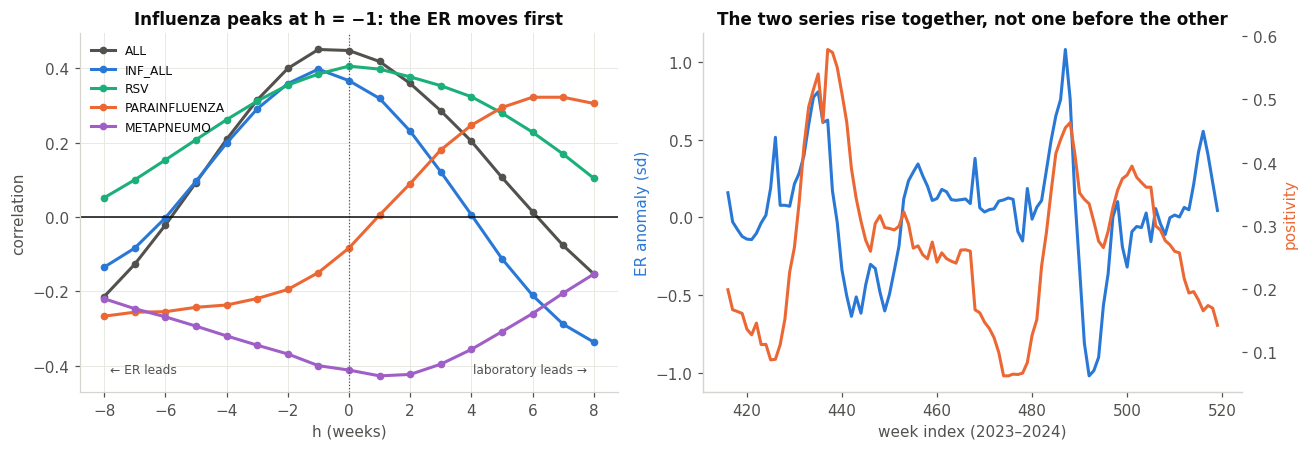

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
show = ["ALL", "INF_ALL", "RSV", "PARAINFLUENZA", "METAPNEUMO"]
cols = [INK_SOFT, BLUE, AQUA, ORANGE, "#a05ec7"]

ax = axes[0]
for name, c in zip(show, cols):
    ax.plot(HS, cx[name], marker="o", markersize=4, linewidth=2, color=c, label=name)
ax.axvline(0, color=INK_SOFT, linewidth=0.8, linestyle=":")
ax.axhline(0, color=INK, linewidth=1)
floor = cx[show].to_numpy().min()
ax.annotate("laboratory leads →", (7.8, floor), ha="right", va="bottom", fontsize=8, color=INK_SOFT)
ax.annotate("← ER leads", (-7.8, floor), ha="left", va="bottom", fontsize=8, color=INK_SOFT)
ax.set_xlabel("h (weeks)"); ax.set_ylabel("correlation")
ax.set_title("Influenza peaks at h = −1: the ER moves first")
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
season_plot = d[d.season.isin([2023, 2024])]
ax2 = ax.twinx()
ax.plot(season_plot.index, season_plot.er, color=BLUE, linewidth=2, label="ER anomaly")
ax2.plot(season_plot.index, season_plot.ALL_pos, color=ORANGE, linewidth=2,
         label="all-virus positivity")
ax.set_ylabel("ER anomaly (sd)", color=BLUE); ax2.set_ylabel("positivity", color=ORANGE)
ax.set_xlabel("week index (2023–2024)")
ax.set_title("The two series rise together, not one before the other")
ax.grid(False); ax2.grid(False)
plt.tight_layout(); plt.show()

**The laboratory is a lagging indicator, and the mechanism is obvious in hindsight.** Influenza
positivity peaks at **h = −1**: it correlates best with the ER anomaly of the *previous* week.
A specimen exists because a patient presented, was swabbed, and the result was processed — the
clinical event comes first and the laboratory confirms it afterwards. RSV peaks at h = 0 and the
all-virus rate at h = −1, which is simultaneity within the resolution of a weekly series.

Two curves do show asymmetry. **Parainfluenza** rises steadily to h = +6 (+0.59 asymmetry) and
**metapneumovirus** is negatively correlated at every lag. Both are phase effects: these viruses
occupy the shoulders of the season, so their timing anomaly co-varies with the *whole season's*
timing anomaly. Whether that is exploitable is not a question correlation can answer — only a
backtest can.

## 2 — The predictive test, five ways

Ridge regression, expanding window: train on every season before the test season, score on the
test season, pooled over seven test seasons. The baseline is the ER series' own history (lags 1, 2,
4 and a four-week change). The question is whether virology adds anything on top.

Four variations, because a null result is only worth believing if it survives the obvious
objections:

| variation | what objection it answers |
| :--- | :--- |
| 2-week publication lag | the honest, deployable setting |
| **oracle**: no lag | "the delay is what kills it" |
| 4-week smoothed | "weekly positivity is too noisy" |
| 2 series only | "thirteen features on 400 rows is overfitting" |

In [5]:
def features(viro_lag, smooth, viro_cols):
    f = d.copy()
    for L in (1, 2, 4):
        f[f"er_l{L}"] = f.er.shift(L)
    f["er_d4"] = f.er - f.er.shift(4)
    for c in viro_cols:
        s = f[c].rolling(smooth, min_periods=1).mean() if smooth > 1 else f[c]
        a = (s - s.groupby(f.week).transform("mean")) / s.std()
        f[c + "_lag"] = a.shift(viro_lag)
        f[c + "_d4"] = a.shift(viro_lag) - a.shift(viro_lag + 4)
    return f


OWN = ["er", "er_l1", "er_l2", "er_l4", "er_d4"]


def backtest(f, cols, h, target="er", by_season=False):
    f = f.copy()
    f["y"] = f[target].shift(-h)
    per, ys, ps = {}, [], []
    for s in TEST_SEASONS:
        tr = f[f.season < s].dropna(subset=cols + ["y"])
        te = f[f.season == s].dropna(subset=cols + ["y"])
        if len(tr) < 60 or not len(te):
            continue
        mdl = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 20)))
        mdl.fit(tr[cols], tr.y)
        y, q = te.y.to_numpy(), mdl.predict(te[cols])
        per[s] = 1 - ((y - q) ** 2).sum() / ((y - y.mean()) ** 2).sum()
        ys.append(y); ps.append(q)
    if by_season:
        return pd.Series(per)
    y, q = np.concatenate(ys), np.concatenate(ps)
    return 1 - ((y - q) ** 2).sum() / ((y - y.mean()) ** 2).sum()


VARIANTS = {
    "2-wk lag (deployable)": dict(viro_lag=2, smooth=1, viro_cols=VCOLS),
    "oracle: no lag":        dict(viro_lag=0, smooth=1, viro_cols=VCOLS),
    "4-wk smoothed":         dict(viro_lag=2, smooth=4, viro_cols=VCOLS),
    "2 series only":         dict(viro_lag=2, smooth=1, viro_cols=["ALL_pos", "RSV_pos"]),
    "oracle + smooth + 2":   dict(viro_lag=0, smooth=4, viro_cols=["ALL_pos", "RSV_pos"]),
}
HORIZONS = [1, 2, 4, 8]

rows = []
for label, kw in VARIANTS.items():
    f = features(**kw)
    viro = [f"{c}_{k}" for c in kw["viro_cols"] for k in ("lag", "d4")]
    for h in HORIZONS:
        own = backtest(f, OWN, h)
        rows.append({"variant": label, "h": h, "own": own,
                     "own+virology": backtest(f, OWN + viro, h)})
res = pd.DataFrame(rows)
res["delta"] = res["own+virology"] - res["own"]
print("Pooled out-of-sample R² on the national ER anomaly\n")
print(res.pivot(index="variant", columns="h", values="delta").round(4)
       .rename(columns=lambda h: f"Δ at h={h}").to_string())
print("\nbaseline (own history alone):")
print(res[res.variant == "2-wk lag (deployable)"].set_index("h")["own"].round(4).to_string())

Pooled out-of-sample R² on the national ER anomaly

h                      Δ at h=1  Δ at h=2  Δ at h=4  Δ at h=8
variant                                                      
2 series only           -0.0296   -0.0775   -0.0836    0.0432
2-wk lag (deployable)   -0.0442   -0.1032   -0.1025   -0.0157
4-wk smoothed           -0.0487   -0.1079   -0.0916   -0.0765
oracle + smooth + 2     -0.0292   -0.0861   -0.1112    0.0253
oracle: no lag          -0.0163   -0.0540   -0.0629   -0.1023

baseline (own history alone):
h
1    0.8289
2    0.5916
4    0.1161
8   -0.2121


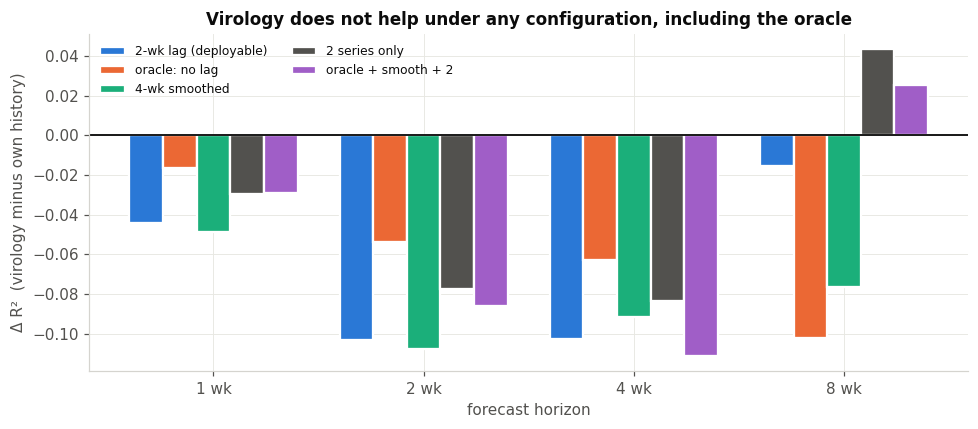

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
piv = res.pivot(index="h", columns="variant", values="delta")
x = np.arange(len(HORIZONS)); w = 0.16
for i, (name, c) in enumerate(zip(VARIANTS, [BLUE, ORANGE, AQUA, INK_SOFT, "#a05ec7"])):
    ax.bar(x + (i - 2) * w, piv[name], w, color=c, edgecolor="white", linewidth=1.5, label=name)
ax.axhline(0, color=INK, linewidth=1.2)
ax.set_xticks(x); ax.set_xticklabels([f"{h} wk" for h in HORIZONS])
ax.set_xlabel("forecast horizon"); ax.set_ylabel("Δ R²  (virology minus own history)")
ax.set_title("Virology does not help under any configuration, including the oracle")
ax.legend(frameon=False, fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

**No configuration helps.** The deployable setting loses R² at all four horizons. The **oracle** —
virology delivered with no publication delay at all, which no real system could provide — is
negative at all four as well. Smoothing makes it worse; cutting to two features makes it worse. Two
variants do post a positive delta, both only at h = 8, where the baseline is −0.21: that is one
broken model beating another, not a forecast. The null is not an artefact of latency, noise, or
dimensionality: the laboratory
simply does not know anything the emergency-room series has not already said.

This closes the last route named in the 2026-07-27 decision log. It is worth being precise about
what was refuted: not that virological surveillance is uninformative about epidemics — it plainly
is — but that it is informative **about ER demand, ahead of ER demand itself**, which is the only
thing that would help here. The ER panel is 622 facilities reporting weekly; the sentinel
laboratory network is a few thousand specimens. The bigger, faster instrument is the one this
project already had.

## 3 — The last in-house candidate: do children lead the elderly?

RSV epidemiology says infants are the amplifying group — the wave builds in creches and schools
before it reaches grandparents. If that holds here, the leading indicator is *inside* the panel:
paediatric demand would forecast elderly demand, and elderly demand is the expensive one, the band
that occupies beds rather than being sent home.

Same test as before, on national per-age-band anomalies (log counts, deseasonalized, standardized).

In [7]:
nat = p.groupby("t")[AGES].sum().reindex(d.index)
A = pd.DataFrame(index=d.index)
for c in AGES:
    s = np.log1p(nat[c])                       # bands differ by an order of magnitude in size
    A[c] = (s - s.groupby(d.week).transform("mean")) / s.std()

print("asymmetry corr(+1) − corr(−1); positive means the row leads the column\n")
asym = pd.DataFrame(index=AGES, columns=AGES, dtype=float)
for a in AGES:
    for b in AGES:
        if a != b:
            asym.loc[a, b] = xcorr(A[b].shift(-1), A[a]) - xcorr(A[b].shift(1), A[a])
print(asym.round(3).fillna("—").to_string())

g = A.join(d[["season", "week"]])
for c in AGES:
    for L in (1, 2, 4):
        g[f"{c}_l{L}"] = g[c].shift(L)
ELD = ["De_65_y_mas"] + [f"De_65_y_mas_l{L}" for L in (1, 2, 4)]
PED = ["Menores_1", "De_1_a_4"] + [f"{c}_l{L}" for c in ("Menores_1", "De_1_a_4") for L in (1, 2, 4)]

print("\n\nforecasting the ELDERLY anomaly — pooled R² across the seven test seasons")
rows = []
for h in (1, 2, 4, 6, 8, 12):
    rows.append({"h": h,
                 "elderly own history": backtest(g, ELD, h, target="De_65_y_mas"),
                 "+ paediatric history": backtest(g, ELD + PED, h, target="De_65_y_mas")})
t = pd.DataFrame(rows).set_index("h")
t["delta"] = t["+ paediatric history"] - t["elderly own history"]
print(t.round(4).to_string())

print("\nthe same h = 8 result, scored WITHIN each season instead of pooled")
w8 = pd.DataFrame({"own": backtest(g, ELD, 8, "De_65_y_mas", by_season=True),
                   "+paediatric": backtest(g, ELD + PED, 8, "De_65_y_mas", by_season=True)})
w8["delta"] = w8["+paediatric"] - w8["own"]
print(w8.round(3).to_string())

asymmetry corr(+1) − corr(−1); positive means the row leads the column

            Menores_1 De_1_a_4 De_5_a_14 De_15_a_64 De_65_y_mas
Menores_1           —   -0.066    -0.057      0.101       0.112
De_1_a_4        0.066        —    -0.018       0.14       0.135
De_5_a_14       0.057    0.018         —      0.134       0.141
De_15_a_64     -0.101    -0.14    -0.134          —       0.077
De_65_y_mas    -0.112   -0.135    -0.141     -0.077           —


forecasting the ELDERLY anomaly — pooled R² across the seven test seasons


    elderly own history  + paediatric history   delta
h                                                    
1                0.8594                0.8508 -0.0086
2                0.7395                0.7299 -0.0096
4                0.4544                0.4448 -0.0096
6                0.2395                0.2692  0.0297
8                0.0888                0.2114  0.1227
12              -0.0494                0.2902  0.3396

the same h = 8 result, scored WITHIN each season instead of pooled
        own  +paediatric  delta
2017 -0.605       -0.409  0.195
2018 -0.102       -0.062  0.040
2019 -0.372       -0.358  0.014
2022 -0.150       -0.180 -0.030
2023 -1.523       -1.507  0.016
2024 -0.766       -0.201  0.565
2025 -3.408       -1.396  2.012


**A trap worth naming, because it nearly produced a false positive.** Pooled across seasons, adding
paediatric history lifts R² at eight weeks from 0.089 to 0.211 — apparently the best result in this
project. Scored *within* each season, both models are **negative in all seven**: −3.4 improving to
−1.4 in 2025, −0.77 to −0.20 in 2024. The pooled figure was rewarding the model for predicting the
average difference *between* seasons, which no hospital needs a model for.

The direction is nonetheless consistent — paediatric bands do lead the elderly band (asymmetry
+0.11 to +0.14, twenty times larger than anything spatial in `03d`), and six of seven seasons
improve. It is a real epidemiological signal. It is not a forecast: "less catastrophically wrong"
is not a product.

## 4 — Where the wall is

Everything above tests *what to add*. This asks the prior question: **how far ahead is this series
forecastable at all?** Own history only, scored within each test season, one column per season so
that a single bad year cannot hide behind an average.

In [8]:
f = features(viro_lag=2, smooth=1, viro_cols=VCOLS)
wall = pd.DataFrame({h: backtest(f, OWN, h, by_season=True) for h in (1, 2, 3, 4, 6, 8)}).T
wall.index.name = "h"
wall["median"] = wall.median(axis=1)
print("Within-season out-of-sample R² on the national ER anomaly (own history)\n")
print(wall.round(3).to_string())

Within-season out-of-sample R² on the national ER anomaly (own history)

    2017   2018   2019   2022   2023   2024   2025  median
h                                                         
1  0.859  0.807  0.841  0.889  0.835  0.775  0.218   0.835
2  0.652  0.497  0.598  0.630  0.657  0.463 -0.327   0.598
3  0.352  0.174  0.435  0.274  0.422  0.140 -0.630   0.274
4  0.086 -0.063  0.272 -0.124  0.220 -0.143 -0.582  -0.063
6 -0.232 -0.302  0.039 -0.810 -0.002 -0.277 -0.541  -0.277
8 -0.266 -0.401 -0.034 -1.052  0.014 -0.154 -0.682  -0.266


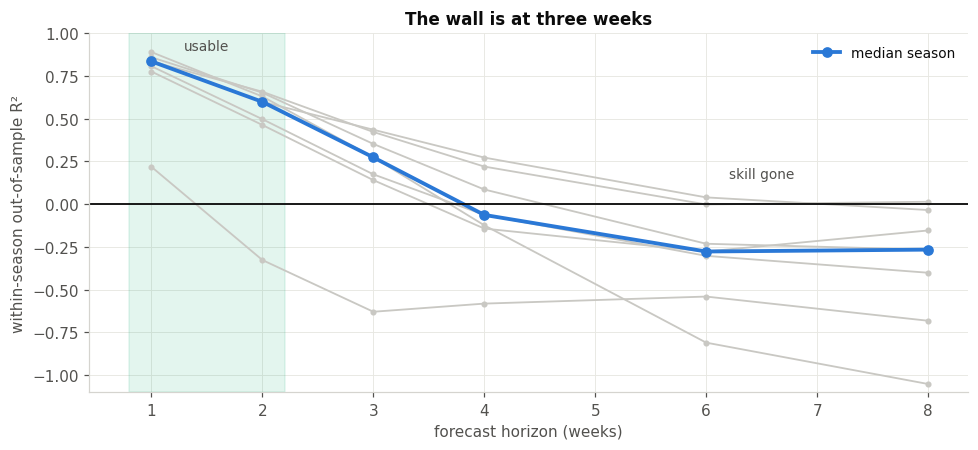

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.2))
hs = wall.index.to_numpy()
for s in TEST_SEASONS:
    ax.plot(hs, wall[s], color="#c9c8c3", linewidth=1.2, marker="o", markersize=3)
ax.plot(hs, wall["median"], color=BLUE, linewidth=2.5, marker="o", markersize=6, label="median season")
ax.axhline(0, color=INK, linewidth=1.2)
ax.axvspan(0.8, 2.2, color=AQUA, alpha=0.12)
ax.annotate("usable", (1.5, 0.9), ha="center", fontsize=9, color=INK_SOFT)
ax.annotate("skill gone", (6.5, 0.15), ha="center", fontsize=9, color=INK_SOFT)
ax.set_ylim(-1.1, 1.0)
ax.set_xlabel("forecast horizon (weeks)"); ax.set_ylabel("within-season out-of-sample R²")
ax.set_title("The wall is at three weeks")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

The obvious response to a three-week wall is to stop forecasting weeks and forecast the *season*
instead — peak timing and peak height, called in early autumn. That fails for a different reason,
and it is worth measuring rather than assuming.

In [10]:
nat_lvl = (load_weekly_target(2015, 2026)
           .groupby(["Anio", "SemanaEstadistica"])[Y].sum().rename("lvl").reset_index())
nat_lvl = nat_lvl[nat_lvl.SemanaEstadistica.between(10, 45)]
pk = nat_lvl.loc[nat_lvl.groupby("Anio").lvl.idxmax()]
pk.columns = ["season", "peak_week", "peak_level"]
print(pk.to_string(index=False))

ok = pk[~pk.season.isin([2020, 2021, 2026])]        # COVID years, and 2026 is still running
print(f"\nusable seasons: {len(ok)}")
print(f"peak week: mean {ok.peak_week.mean():.1f}, sd {ok.peak_week.std():.1f}, "
      f"range {ok.peak_week.min()}-{ok.peak_week.max()}")
print(f"corr(peak week, previous season's):  {ok.peak_week.corr(ok.peak_week.shift(1)):+.2f}")
print(f"corr(peak level, previous season's): {ok.peak_level.corr(ok.peak_level.shift(1)):+.2f}")

 season  peak_week  peak_level
   2015         33    168141.0
   2016         26    159274.0
   2017         23    177420.0
   2018         33    141037.0
   2019         24    161692.0
   2020         12    101595.0
   2021         45     45700.0
   2022         44    160298.0
   2023         20    188451.0
   2024         20    202245.0
   2025         21    139508.0
   2026         24    153243.0

usable seasons: 9
peak week: mean 27.1, sd 8.1, range 20-44
corr(peak week, previous season's):  -0.25
corr(peak level, previous season's): -0.18


**Nine usable seasons, and last season tells you nothing about this one** — the peak week's
autocorrelation is −0.25, the peak level's −0.18. A season-level model has nine rows to learn from
and no autoregressive structure to exploit. That is not a training set; it is an anecdote with a
standard deviation.

## 5 — Verdict: what VitalFlow is

**The horizon wall is at three weeks, and it is sharp.** Median within-season R² on the national
anomaly runs **0.84 at one week, 0.60 at two, 0.28 at three, and −0.06 at four**. Beyond that every
season is negative. That number is now measured against every predictor this project can reach:
the facility's own history (`03c`), its neighbours at any distance (`03d`), the national index
(`03d`), laboratory virological surveillance (§2 above) and the paediatric bands (§3). None of them
moves the wall.

**So the deliverable is a 1-to-2-week horizon, and the project should say so.** That is not the
4-to-8-week promise the original definition made, and pretending otherwise would mean shipping an
alert list that a wall calendar matches. What one-to-two weeks buys a hospital is real but specific:
shift rescheduling, calling in relief staff, opening contingency beds, deferring elective procedures
— not hiring, which is what needed two months.

**The model that fits this problem is small.** The measurements dictate the architecture:

1. **Forecast one series, not 622.** The anomaly is a single national wave (`03d`). At h = 1–2 it
   is highly predictable (R² 0.84 / 0.60) from its own recent history.
2. **Allocate it to facilities.** Each facility's forecast is its own week-of-year climatology plus
   its loading on the national anomaly — a factor model, matching the measured 60/20/13 variance
   split exactly.
3. **Rank, do not threshold.** The deliverable is an alert list under a fixed budget, so the model
   should output a surge *probability* per facility-week and rank on it. A classifier trained on the
   binary surge event optimises the actual decision; every model so far optimised a conditional mean
   and then thresholded it, which is what let a higher R² coexist with an unchanged alert list.

**What is explicitly not justified:** a Temporal Fusion Transformer (n ≈ 500 weekly observations for
the wave; no cross-facility structure to attend over), HDBSCAN clustering (`03d`), a pollution
feature (`03b`), and any season-ahead model — nine usable seasons is not a training set, and the
peak week's autocorrelation between consecutive seasons is −0.25.